## Portfolio 2 - Text classification benchmarks - src2, neural network

*By Sofie Mosegaard, 07-03-2024*

In this assignment, I will train a simple (binary) classification model on text data using ```scikit-learn```. The assignment will consist of *two different scripts*. In the first script, I will train a logistic regression classifier. In the second script, I will train a neural network. 

This is the **second script** and will therefore contain code, that trains a neural network:

### Import packages

In [2]:
# System tools
import os
import sys
import scipy as sp

# Data munging tools
import pandas as pd

# Machine learning packages
from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

# Visualisation
import matplotlib.pyplot as plt

# Save models
from joblib import dump, load

### Reading in the data

In [3]:
# Load the data to pandas csv
filepath = os.path.join(
                        "..",
                        "in",
                        "fake_or_real_news.csv"
                        )

data = pd.read_csv(filepath)

In [4]:
# Create the data variables
X = data["text"]
y = data["label"]

### Train-test split

Creating a 80:20 train:test split in the data using the input X (the text for the model) and y (the classification labels). To ensure reproducibility, a random state of 123 is included.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,    
                                                    test_size = 0.2,
                                                    random_state = 123)

### Import the vectorized features

As I have already created a vectorizer object and fitted that to my training and test data, I can simply import the objects:

In [6]:
X_train_features = sp.sparse.load_npz('../models/X_train_features_sparse_matrix.npz')
X_test_features = sp.sparse.load_npz('../models/X_test_features_sparse_matrix.npz')

### Classifying and predicting

Now, I need to fit my classifier to the data, where it will idenfity correlation between the features and labels. These correlations forms the "model", that the classifier learns. Subsequently, the model can predict labels for unseen data.

The neural network classifier will use a logistic Sigmoid activation function for the hidden layers. Additionally, will the classifier contain one hidden layer consisting of 20 neurons and have a maximum of 1000 iterations during training to control the training process and decrese the risk of overfitting with too many iterations.

In [7]:
classifier = MLPClassifier(activation = "logistic",
                           hidden_layer_sizes = (20,),
                           max_iter = 1000,
                           random_state = 123)

# Fit the classifier to the training data
NN_classifier = classifier.fit(X_train_features, y_train)

In [8]:
# Predicting labels for new, unseen data using the trained classifier
y_pred = NN_classifier.predict(X_test_features)

# Printing the predicted labels for the first 10 samples
print(y_pred[:10])

['FAKE' 'FAKE' 'FAKE' 'FAKE' 'REAL' 'FAKE' 'FAKE' 'FAKE' 'FAKE' 'REAL']


### Evaluate

Lets assess the performance of the model! The models performances can be evaluated on a confusion matrix and metrics derived from one. The confusion matrix takes the classifier, the training features, and the training labels as inputs:

              precision    recall  f1-score   support

        FAKE       0.89      0.91      0.90       644
        REAL       0.90      0.88      0.89       623

    accuracy                           0.89      1267
   macro avg       0.89      0.89      0.89      1267
weighted avg       0.89      0.89      0.89      1267



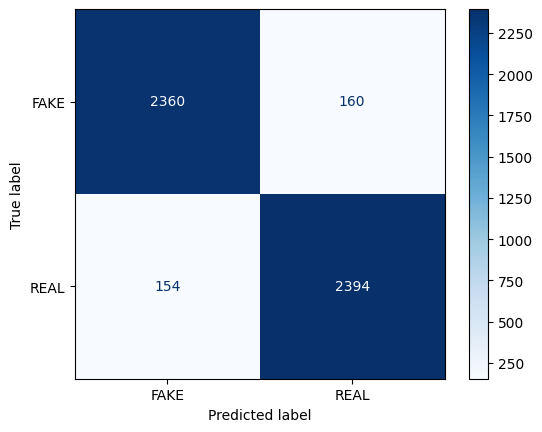

In [9]:
metrics.ConfusionMatrixDisplay.from_estimator(NN_classifier,
                                            X_train_features,
                                            y_train,
                                            cmap = plt.cm.Blues,
                                            labels = ["FAKE", "REAL"])

classifier_metrics = metrics.classification_report(y_test, y_pred)
print(classifier_metrics)

__Plotting loss curves__

To examine how well the model learns, a loss curve can be plotted.

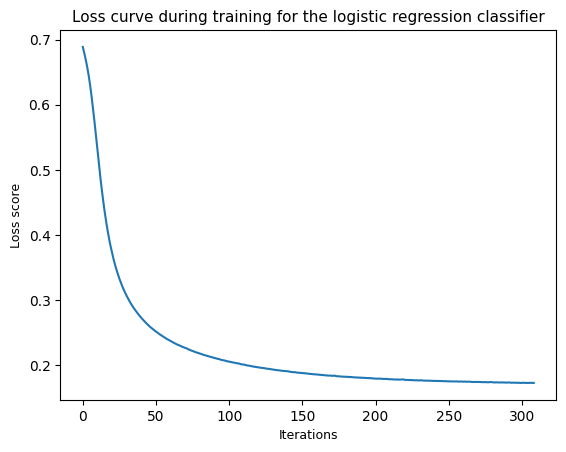

In [14]:
plt.plot(NN_classifier.loss_curve_)
plt.title("Loss curve during training for the logistic regression classifier", fontsize = 11)
plt.xlabel('Iterations', size = 9)
plt.ylabel('Loss score', size = 9)
plt.show()

# It can be seen, that the model is learning well.

### Save the classification report

In [20]:
filepath = "../out/NeuralNetwork_classification_report.txt"

with open(filepath, 'w') as file:
    file.write(classifier_metrics)

### Save the trained model

In [16]:
dump(NN_classifier, "../models/NeuralNetwork_classifier.joblib")


['../models/NeuralNetwork_classifier.joblib']